In [1]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from qcm.data.band import BandDataset
import matplotlib.pyplot as plt


# Hybrid Hamiltonian Model

This notebook illustrates the usage of the hybrid QNN model on a very simple toy dataset


## Band dataset

The dataset used consists of square pictures with either veritcal or horizontal bands. The size of each picture as well as the number of samples in the dataset can be easily controlled with the arguments of the class.

In [2]:
train_dataset = BandDataset(image_size=16, num_samples=1000, num_channels=1)
valid_dataset = BandDataset(image_size=16, num_samples=200, num_channels=1)

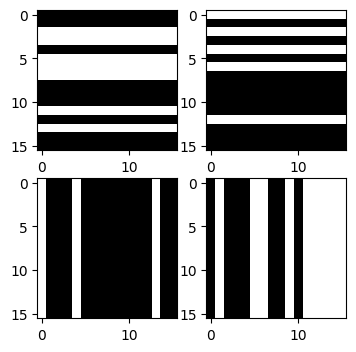

In [3]:

imgs = [train_dataset[idx][0] for idx in range(4)]
fig, axs = plt.subplots(2, 2, figsize=(4, 4))
for i in range(2):
    for j in range(2):
        axs[i,j].imshow(imgs[i+2*j][0, ...], cmap='gray')
plt.show()

In [4]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=False)

## Hamiltonian Model

In [ ]:
import lightning as L 

class HybridModel(L.LightningModule):
    def __init__(self, encoder, hamiltonian, learning_rate=1e-3):
        super().__init__()
        self.encoder = encoder
        self.ham = hamiltonian
        self.learning_rate = learning_rate

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoder(x)
        return self.ham(x)

    def training_step(self, batch):
        x, y = batch
        loss = self.forward(x).mean()
        return loss

    def configure_optimizers(self):
        optimizer = Adam(self.parameters(), lr=self.learning_rate)
        scheduler = CosineAnnealingLR(optimizer, T_max=10)
        return [optimizer], [scheduler]

(<Figure size 1900x500 with 1 Axes>, <Axes: >)


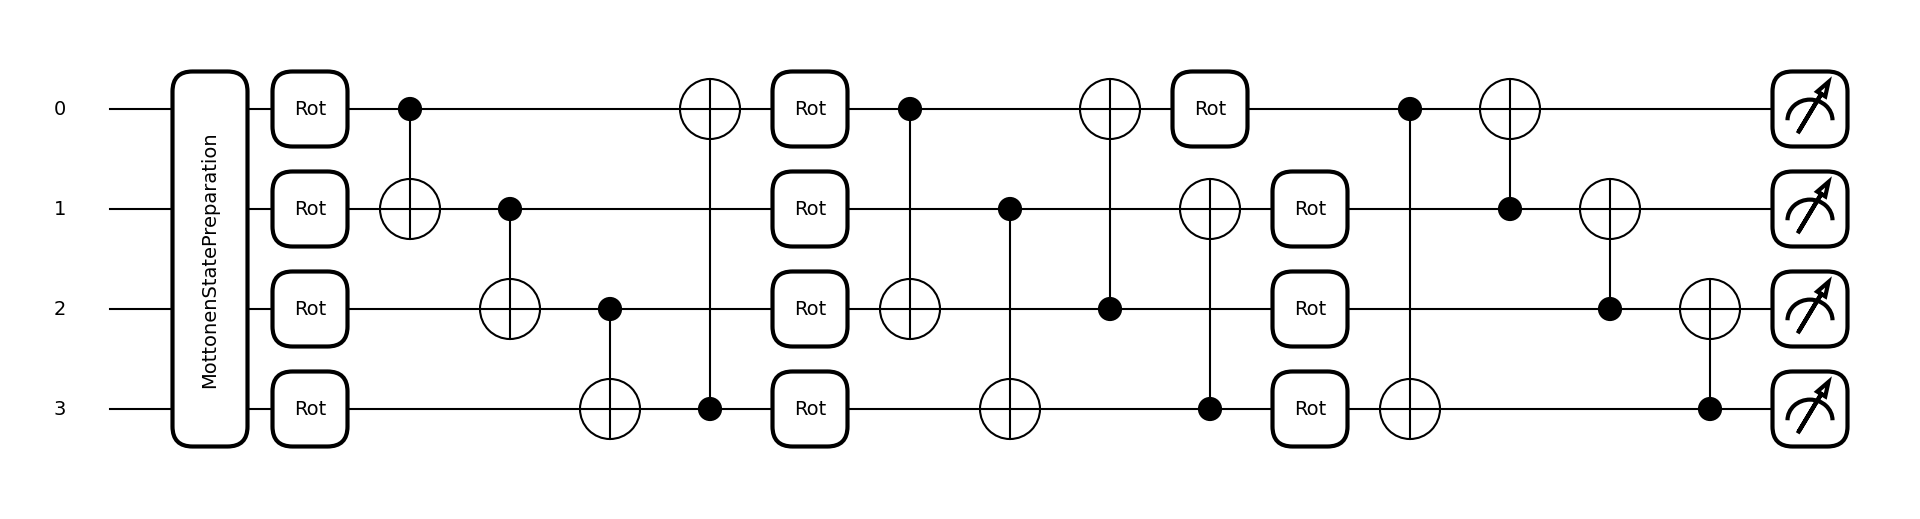

In [9]:
from qcm.components.encoder.band import BandEncoder
from qcm.components.qnn.amplitude_encoding import QuantumHeadAmplitude 
import pennylane as qml

encoder = BandEncoder(filters = 6, latent_dim = 16)
qnn = QuantumHeadAmplitude(n_qubits=4, num_classes=2, n_layers=3)
model = HybridModel(encoder, qnn)
model.qnn.draw_circuit()

In [12]:
trainer = L.Trainer(max_epochs=20, accelerator='cpu', devices=1, logger=False)
trainer.fit(model, train_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                 | Params | Mode 
---------------------------------------------------------
0 | encoder | BandEncoder          | 1.5 K  | train
1 | qnn     | QuantumHeadAmplitude | 46     | train
---------------------------------------------------------
1.6 K     Trainable params
0         Non-trainable params
1.6 K     Total params
0.006     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|██████████| 32/32 [00:00<00:00, 73.63it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 32/32 [00:00<00:00, 72.89it/s]
